In [ ]:
import numpy as np
import scipy.constants as sc
import catppuccin
import matplotlib.pyplot as plt
import adri
from pygmid import Lookup as lk
pmos4 = lk('lookup_table/035/pmos4.mat')
nmos4 = lk('lookup_table/035/nmos4.mat')
#import adri as adri
#22H17
# setup matplotlib
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.spines.top'] = False
plt.rcParams.update({"axes.grid": True})
from scipy.interpolate import interp1d
def interp1(x, y, value):
    # Interpolation function
    # Perform cubic interpolation using interp1d
    f = interp1d(x, y, kind='cubic')
    return f(value)
from IPython.display import display, HTML
def print_design_summary(s, d, m1, m2, m3, m4, p):
    def make_table(title, blk):
        items = [(k, fmt(np.asarray(v).flat[0] if not np.isscalar(v) else v, k))
                 for k, v in blk.items()]
        header = f"<tr><td colspan='2' style='padding:8px 0 3px; font-size:20px; letter-spacing:.1em; opacity:.5; text-transform:uppercase; border-top:1px solid currentColor;'>{title}</td></tr>"
        rows = "".join(
            f"<tr><td style='padding:1px 4px 1px 0; opacity:.6; white-space:nowrap'>{k}</td>"
            f"<td style='padding:1px 0; text-align:right; font-variant-numeric:tabular-nums; font-weight:500; white-space:nowrap'>{v}</td></tr>"
            for k, v in items)
        footer = "<tr><td colspan='2' style='border-top:1px solid currentColor; padding-top:2px'></td></tr>"
        return f"<table style='font-family:monospace; font-size:18px; border-collapse:collapse; color:inherit; vertical-align:top'>{header}{rows}{footer}</table>"

    tables = ""
    for title, blk in [("Specifications", s), ("Design parameters", d),
                        ("M1", m1), ("M2", m2), ("M3", m3), ("M4", m4), ("P", p)]:
        tables += f"<td style='vertical-align:top; padding-right:0px'>{make_table(title, blk)}</td>"

    display(HTML(f"<table style='color:inherit; border-spacing:; border-collapse:collapse'><tr>{tables}</tr></table>"))
def fmt(val, key=""):
    if not isinstance(val, (int, float, np.floating)):
        return str(val)
    a = abs(val)
    if   a >= 1e9:  return f"{val/1e9:.4g} G"
    elif a >= 1:    return f"{val:.4g}"
    elif a >= 1e-3: return f"{val/1e-3:.4g} m"
    elif a >= 1e-6: return f"{val/1e-6:.4g} u"
    elif a >= 1e-9: return f"{val/1e-9:.4g} n"
    elif a >= 1e-12:return f"{val/1e-12:.4g} p"
    else:           return f"{val:.4e}"


# Two-Stage OTA for Switched-Capacitor Circuits

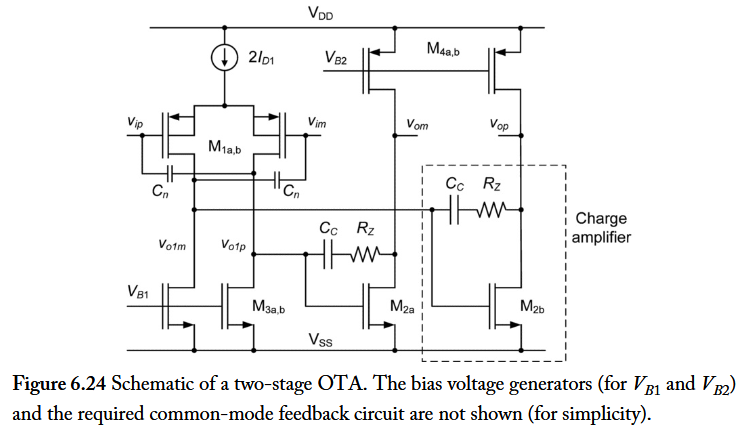

## Formulas :
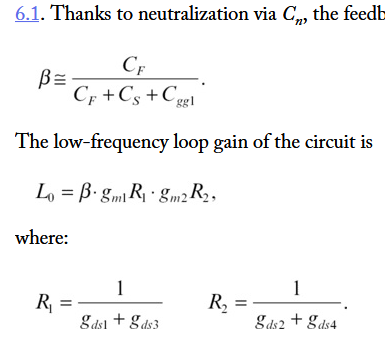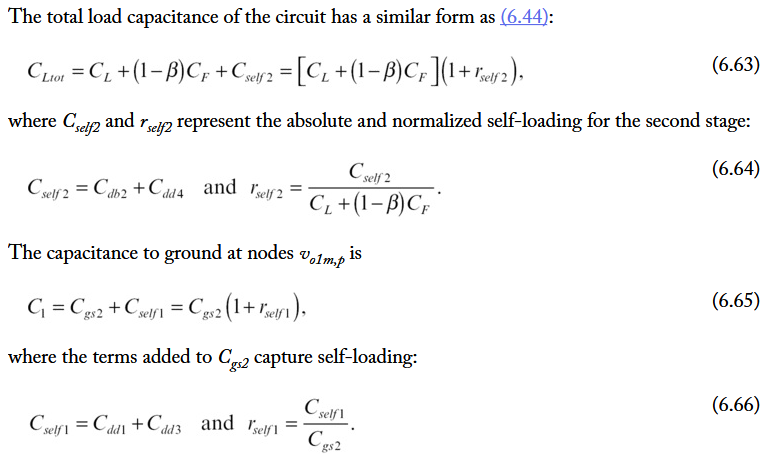  
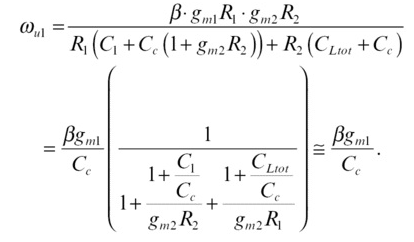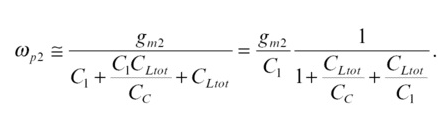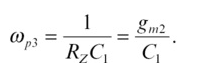  
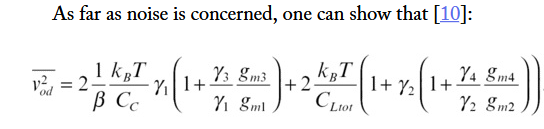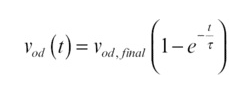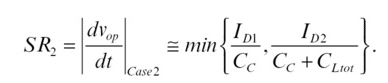  
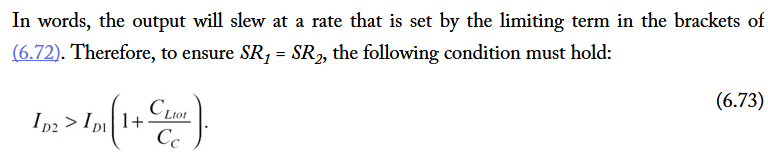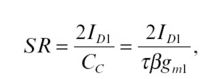  
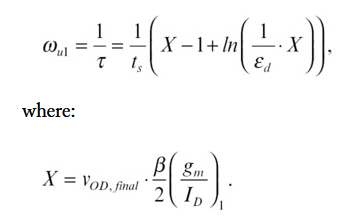

## Method 1 : Find lowest current
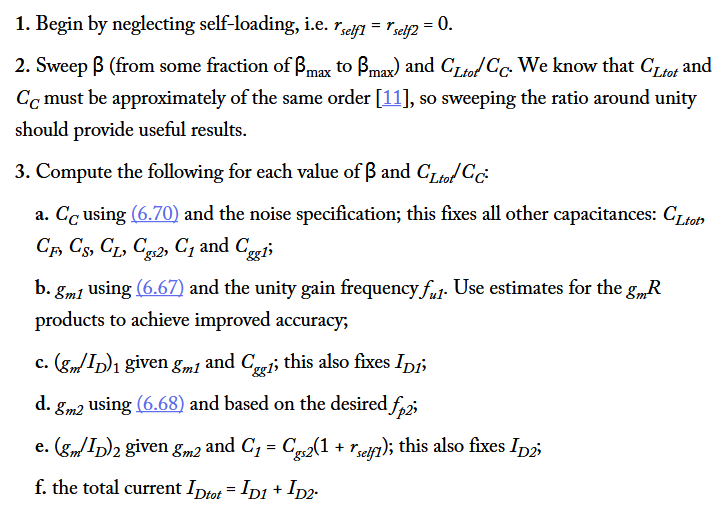  
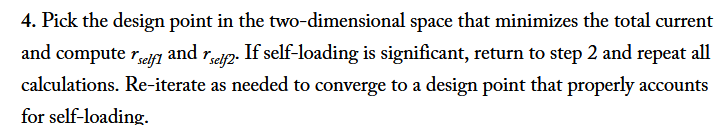

### Loop to find lowest current point

In [ ]:
#Design Spec 
s = {
    'G'         : 1/4,
    'FO'        : 4,
    'fu1'       : 0,
    'fp2'       : 0,
    'vod_noise' : 90e-6,
    'L0' : 50,
    'ts' : 50e-9,
}
beta_max = 1 / (1 + s['G'])
s['fu1'] = 1/(2*np.pi) * np.log(1/ (0.1/100)) / s['ts']
s['fp2'] = s['fu1'] * 4.0

# Constants for another design
d = {
    'L1': 0.5,
    'L4': 0.5,
    'L2': 0.5,
    'L3': 0.5,
    'gam1': 0.8,
    'gam4': 0.8,
    'gam2': 0.8,
    'gam3': 0.8,
    'gm3_gm1': 1.0,
    'gm4_gm2': 0.5,
    'cgs2_cc': 0.5,
    'rself_1': 0,
    'rself_2': 0,
    'beta': beta_max * np.linspace(0.4, 0.9, 30),
    'cltot_cc': np.linspace(0.2, 1.5, 30)
    }


def two_stage(nmos, pmos, s, d):
    kBT = 1.3806488e-23 * 300
    beta_arr     = np.atleast_1d(d['beta'])
    cltot_cc_arr = np.atleast_1d(d['cltot_cc'])
    N = len(beta_arr)   # axe 0
    M = len(cltot_cc_arr)  # axe 1
    m1 = {k: np.full((N, M), np.nan) for k in ['W','gm','gmid','cgg','cgd','cdd','ft','id']}
    m2 = {k: np.full((N, M), np.nan) for k in ['W','gm','gmid','cgg','cgd','cdd','ft','id','cgs','fts']}
    m3 = {k: np.full((N, M), np.nan) for k in ['W','gmid','cdd']}
    m4 = {k: np.full((N, M), np.nan) for k in ['W','gmid','cdd']}
    p  = {k: np.full((N, M), np.nan) for k in ['cc','cltot','cf','cs','cl','c1','rz','cn','rself1','rself2','cc_add']}
    m1['L'] = d['L1']
    m2['L'] = d['L2']
    m3['L'] = d['L3']
    m4['L'] = d['L4']

    for j, beta in enumerate(beta_arr):  # j = indice beta → ligne [j,:]
        cc    = (2/beta * kBT * d['gam1'] * (1 + d['gam3']/d['gam1'] * d['gm3_gm1'])
               + 1/cltot_cc_arr * kBT * (1 + d['gam2'] * (1 + d['gam4']/d['gam2'] * d['gm4_gm2']))
               ) / s['vod_noise']**2
        cltot = cc * cltot_cc_arr
        cf    = cltot / (1 + d['rself_2']) / (1 - beta + s['FO'] * s['G'])
        cs    = cf * s['G']
        cl    = cs * s['FO']
        cgs2  = cc * d['cgs2_cc']
        c1    = cgs2 * (1 + d['rself_1'])

        gmR    = np.sqrt(s['L0'] / beta)
        gm1    = (2*np.pi * s['fu1'] * cc / beta
                  * (1 + (1 + c1/cc) / gmR + (1 + cltot/cc) / gmR))
        cgg1   = cf * (1/beta - 1 - s['G'])
        ft1    = gm1 / (2*np.pi * cgg1)
        gmid1  = pmos.lookup('GM_ID', GM_CGG=2*np.pi*ft1, L=d['L1'], WARNING=False)
        id1    = gm1 / gmid1

        gm2    = 2*np.pi * s['fp2'] * c1 * (1 + cltot/cc + cltot/c1)
        fts2   = gm2 / (2*np.pi * cgs2)
        gmid2  = nmos.lookup('GM_ID', GM_CGS=2*np.pi*fts2, L=d['L2'], WARNING=False)
        id2    = gm2 / gmid2

        # Storage [j,:] → ligne j = beta j, colonnes = tous les cltot_cc
        p['cc'][j,:]     = cc
        p['cltot'][j,:]  = cltot
        p['cf'][j,:]     = cf
        p['cs'][j,:]     = cs
        p['cl'][j,:]     = cl
        p['c1'][j,:]     = c1
        m2['cgs'][j,:]   = cgs2
        m1['gm'][j,:]    = gm1
        m1['cgg'][j,:]   = cgg1
        m1['ft'][j,:]    = ft1
        m1['gmid'][j,:]  = gmid1
        m1['id'][j,:]    = id1
        m2['gm'][j,:]    = gm2
        m2['fts'][j,:]   = fts2
        m2['gmid'][j,:]  = gmid2
        m2['id'][j,:]    = id2
        p['rz'][j,:]     = 1 / gm2

        m3['gmid'][j,:]  = gmid1 * d['gm3_gm1']
        m4['gmid'][j,:]  = gmid2 * d['gm4_gm2']
        m1['W'][j,:]     = id1 / pmos.lookup('ID_W', GM_ID=gmid1, L=d['L1'], WARNING=False)
        m2['W'][j,:]     = id2 / nmos.lookup('ID_W', GM_ID=gmid2, L=d['L2'], WARNING=False)
        m3['W'][j,:]     = id1 / nmos.lookup('ID_W', GM_ID=m3['gmid'][j,:], L=d['L3'], WARNING=False)
        m4['W'][j,:]     = id2 / pmos.lookup('ID_W', GM_ID=m4['gmid'][j,:], L=d['L4'], WARNING=False)

        m1['cgd'][j,:]   = m1['W'][j,:] * pmos.lookup('CGD_W', GM_ID=gmid1, L=d['L1'], WARNING=False)
        p['cn'][j,:]     = m1['cgd'][j,:]
        m2['cgd'][j,:]   = m2['W'][j,:] * nmos.lookup('CGD_W', GM_ID=gmid2, L=d['L2'], WARNING=False)
        p['cc_add'][j,:] = cc - m2['cgd'][j,:]

        m1['cdd'][j,:]   = m1['W'][j,:] * pmos.lookup('CDD_W', GM_ID=gmid1, L=d['L1'], WARNING=False)
        m2['cdd'][j,:]   = m2['W'][j,:] * nmos.lookup('CDD_W', GM_ID=gmid2, L=d['L2'], WARNING=False)
        m3['cdd'][j,:]   = m3['W'][j,:] * nmos.lookup('CDD_W', GM_ID=m3['gmid'][j,:], L=d['L3'], WARNING=False)
        m4['cdd'][j,:]   = m4['W'][j,:] * pmos.lookup('CDD_W', GM_ID=m4['gmid'][j,:], L=d['L4'], WARNING=False)

        p['rself1'][j,:] = (m1['cdd'][j,:] + m3['cdd'][j,:]) / m2['cgs'][j,:]
        p['rself2'][j,:] = ((m2['cdd'][j,:] - m2['cgd'][j,:]) + m4['cdd'][j,:]) / (cl + (1 - beta) * cf)

    return m1, m2, m3, m4, p


m1,m2,m3,m4,p = two_stage(nmos4, pmos4, s, d)

ID1 = m1['id']
ID2 = m2['id']
GMID1 = m1['gmid']
GMID2 = m2['gmid']

ID_TOT = ID1 + ID2

idx = np.nanargmin(ID_TOT)

idx_beta, idx_cl = np.unravel_index(idx, ID_TOT.shape)

IDtot_opt    = ID_TOT[idx_beta, idx_cl]
cltot_cc_opt = d['cltot_cc'][idx_cl]
beta_opt     = d['beta'][idx_beta]

print(f"cltot_cc_opt      = {cltot_cc_opt:.4f}")
print(f"beta_opt/beta_max = {beta_opt/beta_max:.4f}")
print(f"IDtot_opt = {IDtot_opt*1e6:.4f}")

# ── Contour plot ─────────────────────────────────────────────────
# ID_TOT est (N_beta, M_cltot) → transpose pour contour(x=beta, y=cltot_cc)
fig, ax = plt.subplots()
cs = ax.contour(d['beta']/beta_max, d['cltot_cc'], ID_TOT.T * 1e6, levels=20, colors='k')
ax.clabel(cs, cs.levels[::2], inline=True, fmt='%d', fontsize=8)
ax.set_xlabel(r'$\beta/\beta_{max}$')
ax.set_ylabel(r'$C_{Ltot}/C_C$')
ax.set_title(r'Contours of $I_{D1}+I_{D2}$ (µA)', fontsize=9, fontweight='normal')

ax.plot(beta_opt/beta_max, cltot_cc_opt, 'ko', markersize=5)
ax.text(beta_opt/beta_max, cltot_cc_opt + 0.05, f'{IDtot_opt*1e6:.0f}', fontsize=9)

plt.show()



### Point with equal slew rate rise / fall

In [ ]:
indicator = ID2 < (ID1 * (1+ d['cltot_cc']))

# ── Contour plot ─────────────────────────────────────────────────
# ID_TOT est (N_beta, M_cltot) → transpose pour contour(x=beta, y=cltot_cc)
fig, ax = plt.subplots()
cs = ax.contour(d['beta']/beta_max, d['cltot_cc'], ID_TOT.T * 1e6, levels=20, colors='k')
ax.clabel(cs, cs.levels[::2], inline=True, fmt='%d', fontsize=8)
ax.set_xlabel(r'$\beta/\beta_{max}$')
ax.set_ylabel(r'$C_{Ltot}/C_C$')
ax.set_title(r'Contours of $I_{D1}+I_{D2}$ With indicator where not equal slew rate (µA)', fontsize=9, fontweight='normal')

ax.plot(beta_opt/beta_max, cltot_cc_opt, 'ko', markersize=5)
ax.text(beta_opt/beta_max, cltot_cc_opt + 0.05, f'{IDtot_opt*1e6:.0f}', fontsize=9)

for i in range(len(d['beta'])):
    for j in range(len(d['cltot_cc'])):
            if(indicator[i,j]):
                #print(j)
                ax.plot(d['beta'][i]/beta_max, d['cltot_cc'][j], 'x', markersize=4, color='r')
plt.show()
#Res points are not equal slew rate


### Self loading plot

In [ ]:
##Self loading loop
d['beta'] = beta_opt
d['cltot_cc'] = cltot_cc_opt
N_iter = 10
rself1 = np.zeros(N_iter)
rself2 = np.zeros(N_iter)
for i in range(N_iter):

    d['rself_1'] = rself1[i]
    d['rself_2'] = rself2[i]
    
    m1,m2,m3,m4,p = two_stage(nmos4, pmos4, s, d)
    

    if i+1 < N_iter:
        rself1[i+1] = p['rself1'].item()
        rself2[i+1] = p['rself2'].item()

        #print("i = ", i)
        #print(p['rself1'])
        #print(p['rself2'])


ID1 = m1['id']
ID2 = m2['id']
GMID1 = m1['gmid']
GMID2 = m2['gmid']

ID_TOT = ID1 + ID2

idx = np.nanargmin(ID_TOT)

idx_beta, idx_cl = np.unravel_index(idx, ID_TOT.shape)
IDtot_opt    = ID_TOT[idx_beta, idx_cl]
cltot_cc_opt = d['cltot_cc']
beta_opt     = d['beta']

print(f"cltot_cc_opt      = {cltot_cc_opt:.4f}")
print(f"beta_opt/beta_max = {beta_opt/beta_max:.4f}")
print(f"IDtot_opt = {IDtot_opt*1e6:.4f}")

xaxis = np.linspace(1,N_iter, N_iter)
adri.coolPlot(xaxis, rself1, "Iteration", "Rself1", "Self loading")
adri.coolPlot(xaxis, rself2, "Iteration", "Rself2", "Self loading")


### Loop to find optimal CGS2_CC

In [ ]:
###LOOP CGS_CSS -> Cself
#Design Spec 
s = {
    'G'         : 2,
    'FO'        : 0.5,
    'fu1'       : 0,
    'fp2'       : 0,
    'vod_noise' : 400e-6,
    'L0' : 50,
    'ts' : 5e-9,
}
beta_max = 1 / (1 + s['G'])
s['fu1'] = 1/(2*np.pi) * np.log(1/ (0.1/100)) / s['ts']
s['fp2'] = s['fu1'] * 6.0

# Constants for another design
d = {
    'L1': 0.15,
    'L4': 0.15,
    'L2': 0.2,
    'L3': 0.2,
    'gam1': 0.8,
    'gam4': 0.8,
    'gam2': 0.8,
    'gam3': 0.8,
    'gm3_gm1': 1.0,
    'gm4_gm2': 0.5,
    'cgs2_cc': 0.5,
    'rself_1': 0,
    'rself_2': 0,
    'beta': beta_max * np.linspace(0.4, 0.9, 10),
    'cltot_cc': np.linspace(0.2, 1.5, 10)
    }

cgs2_cc_iter = 10
rself_iter = 5
cgs2_cc = np.linspace(0.1,0.6,cgs2_cc_iter)

rself1 = np.zeros(rself_iter)
rself2 = np.zeros(rself_iter)
rself1_out = np.zeros(rself_iter)
rself2_out = np.zeros(rself_iter)

ITOT_PLOT = np.zeros(cgs2_cc_iter)
CGS2_CC_PLOT = np.zeros(cgs2_cc_iter)

for k in range(len(cgs2_cc)):
    d['cgs2_cc'] = cgs2_cc[k]
    for i in range(rself_iter):
        d['rself_1'] = rself1[i]
        d['rself_2'] = rself2[i]
        m1,m2,m3,m4,p = two_stage(nmos4, pmos4, s, d)
    
    #print(p['rself1'])
    ID1 = m1['id']
    ID2 = m2['id']
    ID_TOT = ID1 + ID2
    idx = np.nanargmin(ID_TOT)
    idx_beta, idx_cl = np.unravel_index(idx, ID_TOT.shape)
    IDtot_opt    = ID_TOT[idx_beta, idx_cl]
    cltot_cc_opt = d['cltot_cc'][idx_cl]
    beta_opt     = d['beta'][idx_beta]
    #Plots
    ITOT_PLOT[k] = IDtot_opt
    CGS2_CC_PLOT[k] = cgs2_cc[k]

    # print(f"rself_iter      = {i:.4f}")
    # print(f"cgs2_cc      = {cgs2_cc[k]:.4f}")
    # print(f"cltot_cc_opt      = {cltot_cc_opt:.4f}")
    # print(f"beta_opt/beta_max = {beta_opt/beta_max:.4f}")
    # print(f"IDtot_opt = {IDtot_opt*1e6:.4f}")

adri.coolPlot(CGS2_CC_PLOT, ITOT_PLOT, "CGS2_CC", "ITOT", "CGS2_CC vs ITOT")

### Loop CGS1_CC -> Self loading -> lowest current (beta, cltot_cc)

In [ ]:
###FInal Design
#Design Spec 
##CGS2_CC loop
####Self loading loop
#######test several beta & gm_id to find lowest current point
s = {
    'G'         : 2,
    'FO'        : 0.5,
    'fu1'       : 0,
    'fp2'       : 0,
    'vod_noise' : 400e-6,
    'L0' : 50,
    'ts' : 50e-9,
}
beta_max = 1 / (1 + s['G'])
s['fu1'] = 1/(2*np.pi) * np.log(1/ (0.1/100)) / s['ts']
s['fp2'] = s['fu1'] * 6.0

# Constants for another design
d = {
    'L1': 0.5,
    'L4': 0.5,
    'L2': 0.5,
    'L3': 0.5,
    'gam1': 0.8,
    'gam4': 0.8,
    'gam2': 0.8,
    'gam3': 0.8,
    'gm3_gm1': 1.0,
    'gm4_gm2': 0.5,
    'cgs2_cc': 0.5,
    'rself_1': 0,
    'rself_2': 0,
    'beta': beta_max * np.linspace(0.4, 0.9, 15),
    'cltot_cc': np.linspace(0.2, 1.5, 15)
    }

cgs2_cc_iter = 1
rself_iter = 5
cgs2_cc = np.linspace(0.1,0.6,cgs2_cc_iter)
cgs2_cc = [0.3]

rself1 = np.zeros(rself_iter)
rself2 = np.zeros(rself_iter)
rself1_out = np.zeros(rself_iter)
rself2_out = np.zeros(rself_iter)

ITOT_PLOT = np.zeros(cgs2_cc_iter)
CGS2_CC_PLOT = np.zeros(cgs2_cc_iter)

for k in range(len(cgs2_cc)):
    d['cgs2_cc'] = cgs2_cc[k]
    for i in range(rself_iter):
        d['rself_1'] = rself1[i]
        d['rself_2'] = rself2[i]
        m1,m2,m3,m4,p = two_stage(nmos4, pmos4, s, d)
    
    #print(p['rself1'])
    ID1 = m1['id']
    ID2 = m2['id']
    ID_TOT = ID1 + ID2
    idx = np.nanargmin(ID_TOT)
    idx_beta, idx_cl = np.unravel_index(idx, ID_TOT.shape)
    IDtot_opt    = ID_TOT[idx_beta, idx_cl]
    cltot_cc_opt = d['cltot_cc'][idx_cl]
    beta_opt     = d['beta'][idx_beta]
    #Plots
    ITOT_PLOT[k] = IDtot_opt
    CGS2_CC_PLOT[k] = cgs2_cc[k]

    print(f"rself_iter number of iteration     = {i:.4f}")
    print(f"cgs2_cc      = {cgs2_cc[k]:.4f}")
    print(f"cltot_cc_opt      = {cltot_cc_opt:.4f}")
    print(f"beta_opt/beta_max = {beta_opt/beta_max:.4f}")
    print(f"IDtot_opt = {IDtot_opt*1e6:.4f}")

#final design
d['cltot_cc'] = cltot_cc_opt
d['beta'] = beta_opt
d['rself_1'] = p['rself1'][idx_beta, idx_cl]
d['rself_2'] = p['rself2'][idx_beta, idx_cl]
if (cgs2_cc_iter > 1):
    d['cgs2_cc'] = cgs2_cc[np.nanargmin(CGS2_CC_PLOT)].item()
else:
     d['cgs2_cc'] = cgs2_cc

m1,m2,m3,m4,p = two_stage(nmos4, pmos4, s, d)

In [ ]:
print_design_summary(s, d, m1, m2, m3, m4, p)

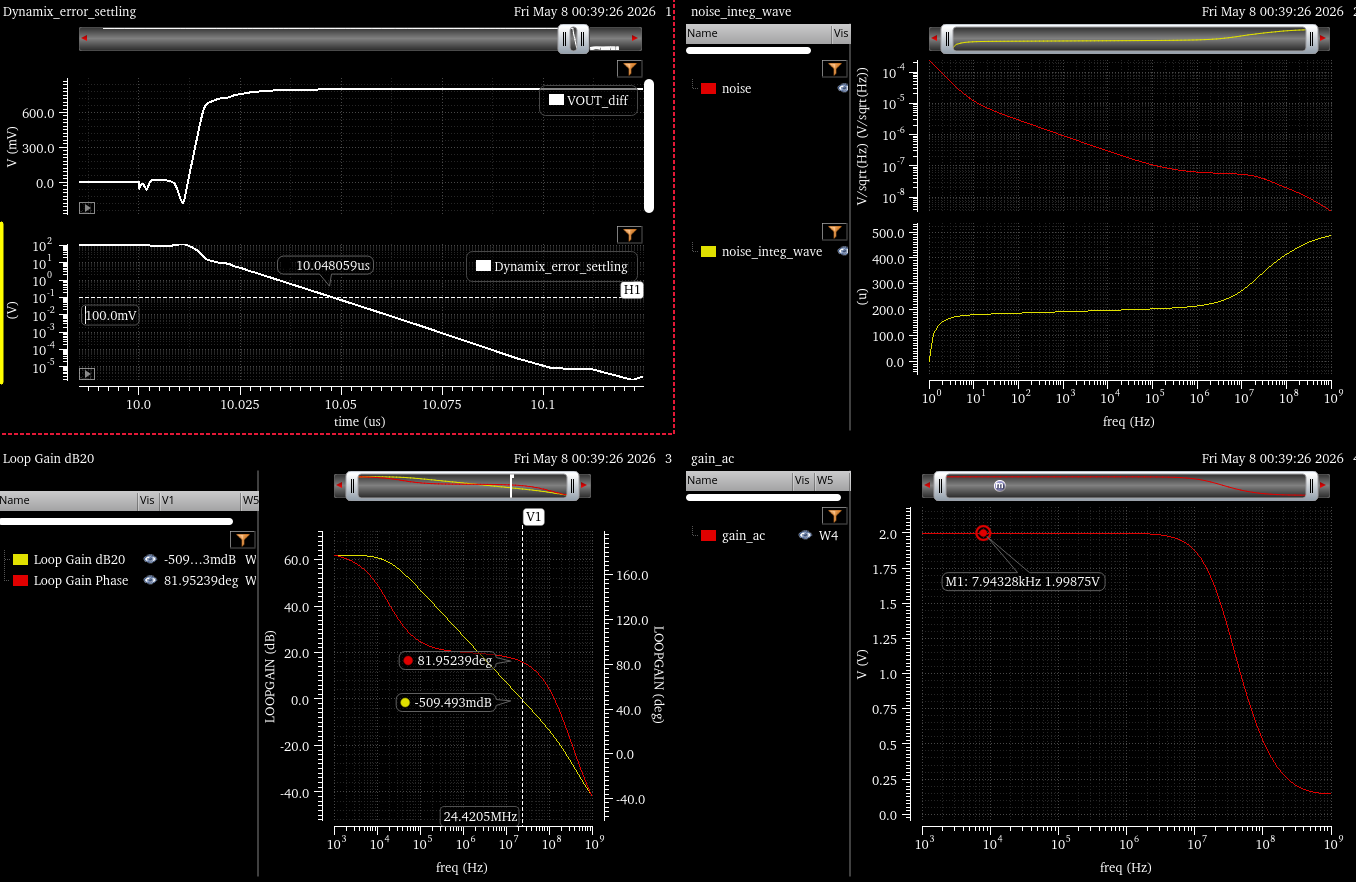  
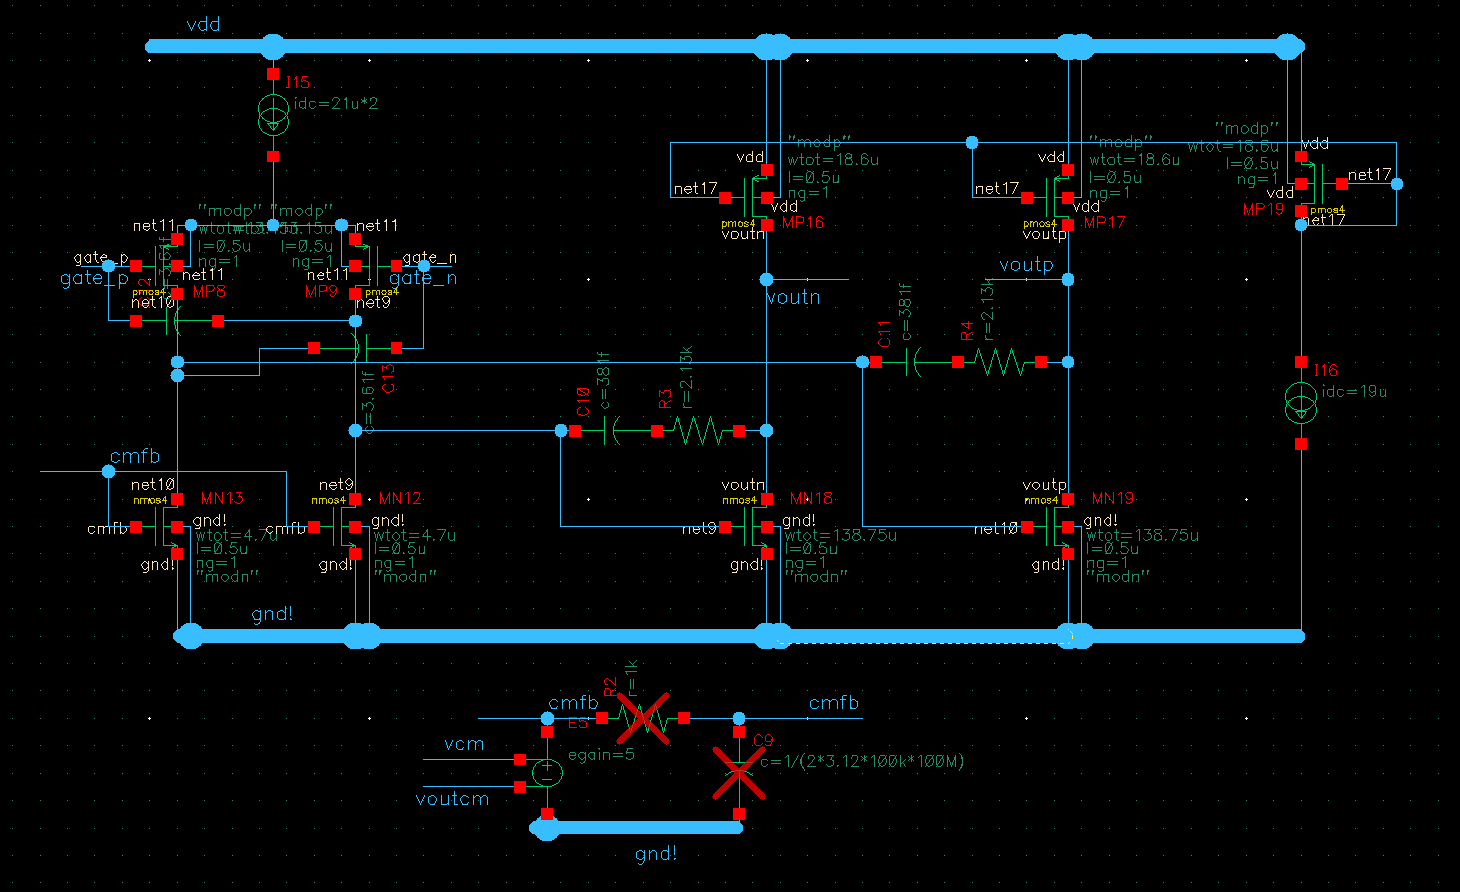  
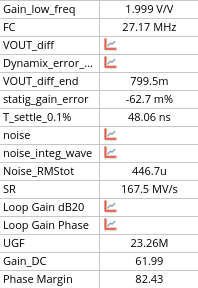

## Methode 2 : Function with Slew rate optimisation 

In [ ]:
#Design Spec 
##Opti with slew rate, Taken into account with X compute
s = {
    'G'         : 2,
    'FO'        : 0.5,
    'fu1'       : 0,
    'fp2'       : 0,
    'vod_noise' : 400e-6,
    'L0' : 50,
    'ts' : 50e-9,
    'vod_final' : 400e-3,
    'ed'    : 0.1/100
}
beta_max = 1 / (1 + s['G'])
s['fu1'] = 1/(2*np.pi) * np.log(1/ (0.1/100)) / s['ts']
s['fp2'] = s['fu1'] * 6.0

# Constants for another design
d = {
    'L1': 0.5,
    'L4': 0.5,
    'L2': 0.5,
    'L3': 0.5,
    'gam1': 0.8,
    'gam4': 0.8,
    'gam2': 0.8,
    'gam3': 0.8,
    'gm3_gm1': 1.0,
    'gm4_gm2': 0.5,
    'cgs2_cc': 0.5,
    'rself_1': 0,
    'rself_2': 0,
    'beta': beta_max * np.linspace(0.4, 0.9, 20),
    'cltot_cc': np.linspace(0.2, 1.5, 20),
    'gm_id_test': np.linspace(1, 30, 30),
    }


def two_stage_sr_opti(nmos, pmos, s, d):
    kBT = 1.3806488e-23 * 300
    beta_arr     = np.atleast_1d(d['beta'])
    cltot_cc_arr = np.atleast_1d(d['cltot_cc'])
    N = len(beta_arr)   # axe 0
    M = len(cltot_cc_arr)  # axe 1
    m1 = {k: np.full((N, M), np.nan) for k in ['W','gm','gmid','cgg','cgd','cdd','ft','id']}
    m2 = {k: np.full((N, M), np.nan) for k in ['W','gm','gmid','cgg','cgd','cdd','ft','id','cgs','fts']}
    m3 = {k: np.full((N, M), np.nan) for k in ['W','gmid','cdd']}
    m4 = {k: np.full((N, M), np.nan) for k in ['W','gmid','cdd']}
    p  = {k: np.full((N, M), np.nan) for k in ['cc','cltot','cf','cs','cl','c1','rz','cn','rself1','rself2','cc_add']}
    m1['L'] = d['L1']
    m2['L'] = d['L2']
    m3['L'] = d['L3']
    m4['L'] = d['L4']

    for j, beta in enumerate(beta_arr):  # j = indice beta → ligne [j,:]
        cc    = (2/beta * kBT * d['gam1'] * (1 + d['gam3']/d['gam1'] * d['gm3_gm1'])
               + 1/cltot_cc_arr * kBT * (1 + d['gam2'] * (1 + d['gam4']/d['gam2'] * d['gm4_gm2']))
               ) / s['vod_noise']**2
        cltot = cc * cltot_cc_arr
        cf    = cltot / (1 + d['rself_2']) / (1 - beta + s['FO'] * s['G'])
        cs    = cf * s['G']
        cl    = cs * s['FO']
        cgs2  = cc * d['cgs2_cc']
        c1    = cgs2 * (1 + d['rself_1'])
        gmR    = np.sqrt(s['L0'] / beta)
        
        gm_id_test = d['gm_id_test'] 
        N_iter_gm_id_test = len(d['gm_id_test'])

        X = np.zeros((N_iter_gm_id_test,M))
    
        wu1 = np.zeros((N_iter_gm_id_test,M))
        gm1 = np.zeros((N_iter_gm_id_test,M))
        cgg1 = np.zeros((N_iter_gm_id_test,M))
        ft1 = np.zeros((N_iter_gm_id_test,M))
        #gmid1 = np.zeros((N_iter_gm_id_test,M))
        id1 = np.zeros((N_iter_gm_id_test,M))
        cgs1 = np.zeros((N_iter_gm_id_test,M))
        cin = np.zeros((N_iter_gm_id_test,M))
        beta_actual = np.zeros((N_iter_gm_id_test,M))

        for k in range(len(gm_id_test)):
            
            X[k,:] = s['vod_final'] * beta / 2 * gm_id_test[k]
            X[k, X[k,:] < 1] = 1
            #wu1[k,:] = 1 / s['ts']*(X[k,:] - 1 + np.log(X[k,:] * 1/s['ed']))
            wu1[k,:] = 1 / s['ts']*(X[k,:] - 1 + np.log(1/(s['ed']*X[k,:])))
            gm1[k,:]    = (wu1[k,:] * cc / beta * (1 + (1 + c1/cc) / gmR + (1 + cltot/cc) / gmR))
            cgg1[k,:]  =  pmos.lookup('CGG_GM', GM_ID=gm_id_test[k], L=d['L1'], WARNING=False) * gm1[k,:]
            cgs1[k,:]  =  pmos.lookup('CGS_GM', GM_ID=gm_id_test[k], L=d['L1'], WARNING=False) * gm1[k,:]
            #cgg1[k,:]   = cf * (1/beta - 1 - s['G'])
            ft1[k,:]    = gm1[k,:] / (2*np.pi * cgg1[k,:])
            #gmid1[k,:]  = pmos.lookup('GM_ID', GM_CGG=2*np.pi*ft1[k,:], L=d['L1'], WARNING=False)
            id1[k,:]    = gm1[k,:] / gm_id_test[k]
            ##Compute input cap for real beta
            #cgs1[k,:] = cgg1[k,:]#gm1[k,:] / (gm1[k] / cgg1[k])
            cin[k,:] = cgs1[k,:]
            beta_actual[k,:] = cf / (cf + cs + cin[k,:])

        #Take closest point to beta, thorw away others
        index_min_gmid = np.argmin(np.abs(beta_actual - beta), axis=0)

        cols = np.arange(M)

        X       = X[index_min_gmid, cols]
        wu1     = wu1[index_min_gmid, cols]
        gm1     = gm1[index_min_gmid, cols]
        cgg1    = cgg1[index_min_gmid, cols]
        ft1     = ft1[index_min_gmid, cols]
        gmid1   = gm_id_test[index_min_gmid]
        id1     = id1[index_min_gmid, cols]
        cgs1    = cgs1[index_min_gmid, cols]
        cin     = cin[index_min_gmid, cols]

        slew_pct = (X - 1) / (X - 1 + np.log(X / s['ed']))
        #print(slew_pct)
        #######Compute actaul beta, find closest to beta, store only this value



        gm2    = 2*np.pi * s['fp2'] * c1 * (1 + cltot/cc + cltot/c1)
        fts2   = gm2 / (2*np.pi * cgs2)
        gmid2  = nmos.lookup('GM_ID', GM_CGS=2*np.pi*fts2, L=d['L2'], WARNING=False)
        id2    = gm2 / gmid2


        # Storage [j,:] → ligne j = beta j, colonnes = tous les cltot_cc
        p['cc'][j,:]     = cc
        p['cltot'][j,:]  = cltot
        p['cf'][j,:]     = cf
        p['cs'][j,:]     = cs
        p['cl'][j,:]     = cl
        p['c1'][j,:]     = c1
        m2['cgs'][j,:]   = cgs2
        m1['gm'][j,:]    = gm1
        m1['cgg'][j,:]   = cgg1
        m1['ft'][j,:]    = ft1
        m1['gmid'][j,:]  = gmid1
        m1['id'][j,:]    = id1
        m2['gm'][j,:]    = gm2
        m2['fts'][j,:]   = fts2
        m2['gmid'][j,:]  = gmid2
        m2['id'][j,:]    = id2
        p['rz'][j,:]     = 1 / gm2

        m3['gmid'][j,:]  = gmid1 * d['gm3_gm1']
        m4['gmid'][j,:]  = gmid2 * d['gm4_gm2']
        m1['W'][j,:]     = id1 / pmos.lookup('ID_W', GM_ID=gmid1, L=d['L1'], WARNING=False)
        m2['W'][j,:]     = id2 / nmos.lookup('ID_W', GM_ID=gmid2, L=d['L2'], WARNING=False)
        m3['W'][j,:]     = id1 / nmos.lookup('ID_W', GM_ID=m3['gmid'][j,:], L=d['L3'], WARNING=False)
        m4['W'][j,:]     = id2 / pmos.lookup('ID_W', GM_ID=m4['gmid'][j,:], L=d['L4'], WARNING=False)

        m1['cgd'][j,:]   = m1['W'][j,:] * pmos.lookup('CGD_W', GM_ID=gmid1, L=d['L1'], WARNING=False)
        p['cn'][j,:]     = m1['cgd'][j,:]
        m2['cgd'][j,:]   = m2['W'][j,:] * nmos.lookup('CGD_W', GM_ID=gmid2, L=d['L2'], WARNING=False)
        p['cc_add'][j,:] = cc - m2['cgd'][j,:]

        m1['cdd'][j,:]   = m1['W'][j,:] * pmos.lookup('CDD_W', GM_ID=gmid1, L=d['L1'], WARNING=False)
        m2['cdd'][j,:]   = m2['W'][j,:] * nmos.lookup('CDD_W', GM_ID=gmid2, L=d['L2'], WARNING=False)
        m3['cdd'][j,:]   = m3['W'][j,:] * nmos.lookup('CDD_W', GM_ID=m3['gmid'][j,:], L=d['L3'], WARNING=False)
        m4['cdd'][j,:]   = m4['W'][j,:] * pmos.lookup('CDD_W', GM_ID=m4['gmid'][j,:], L=d['L4'], WARNING=False)

        p['rself1'][j,:] = (m1['cdd'][j,:] + m3['cdd'][j,:]) / m2['cgs'][j,:]
        p['rself2'][j,:] = ((m2['cdd'][j,:] - m2['cgd'][j,:]) + m4['cdd'][j,:]) / (cl + (1 - beta) * cf)

    return m1, m2, m3, m4, p


m1,m2,m3,m4,p = two_stage_sr_opti(nmos4, pmos4, s, d)

ID1 = m1['id']
ID2 = m2['id']
GMID1 = m1['gmid']
GMID2 = m2['gmid']

ID_TOT = ID1 + ID2

idx = np.nanargmin(ID_TOT)

idx_beta, idx_cl = np.unravel_index(idx, ID_TOT.shape)

IDtot_opt    = ID_TOT[idx_beta, idx_cl]
GMID_opt    = GMID1[idx_beta, idx_cl]
cltot_cc_opt = d['cltot_cc'][idx_cl]
beta_opt     = d['beta'][idx_beta]

print(f"cltot_cc_opt      = {cltot_cc_opt:.4f}")
print(f"GMID_opt      = {GMID_opt:.4f}")
print(f"beta_opt/beta_max = {beta_opt/beta_max:.4f}")
print(f"IDtot_opt = {IDtot_opt*1e6:.4f}")

# ── Contour plot ─────────────────────────────────────────────────
# ID_TOT est (N_beta, M_cltot) → transpose pour contour(x=beta, y=cltot_cc)
fig, ax = plt.subplots()
cs = ax.contour(d['beta']/beta_max, d['cltot_cc'], ID_TOT.T * 1e6, levels=20, colors='k')
ax.clabel(cs, cs.levels[::2], inline=True, fmt='%d', fontsize=8)
ax.set_xlabel(r'$\beta/\beta_{max}$')
ax.set_ylabel(r'$C_{Ltot}/C_C$')
ax.set_title(r'Contours of $I_{D1}+I_{D2}$ (µA)', fontsize=9, fontweight='normal')

ax.plot(beta_opt/beta_max, cltot_cc_opt, 'ko', markersize=5)
ax.text(beta_opt/beta_max, cltot_cc_opt + 0.05, f'{IDtot_opt*1e6:.0f}', fontsize=9)

plt.show()



### Loop with : cgs2_cc -> self loading -> lowest current with Slew Rate

In [ ]:
###FInal Design
#Design Spec 
##CGS2_CC loop
####Self loading loop
#######test several beta & gm_id to find lowest current point
#=> Take point with lowest current for CGS2_CC
s = {
    'G'         : 1/4,
    'FO'        : 4,
    'fu1'       : 0,
    'fp2'       : 0,
    'vod_noise' : 90e-6,
    'L0' : 50,
    'ts' : 50e-9,
    'vod_final' : 160e-3,
    'ed'    : 0.05/100
}
beta_max = 1 / (1 + s['G'])
s['fu1'] = 1/(2*np.pi) * np.log(1/ (0.1/100)) / s['ts']
s['fp2'] = s['fu1'] * 6.0

# Constants for another design
d = {
    'L1': 0.5,
    'L4': 0.5,
    'L2': 0.5,
    'L3': 0.5,
    'gam1': 0.8,
    'gam4': 0.8,
    'gam2': 0.8,
    'gam3': 0.8,
    'gm3_gm1': 1.0,
    'gm4_gm2': 0.5,
    'cgs2_cc': 0.5,
    'rself_1': 0,
    'rself_2': 0,
    'beta': beta_max * np.linspace(0.4, 0.9, 10),
    'cltot_cc': np.linspace(0.2, 1.5, 10),
    'gm_id_test': np.linspace(1, 30,15),
    }

cgs2_cc_iter = 8
rself_iter = 4
cgs2_cc = np.linspace(0.1,0.6,cgs2_cc_iter)
#cgs2_cc = [0.3]

rself1 = np.zeros(rself_iter)
rself2 = np.zeros(rself_iter)
rself1_out = np.zeros(rself_iter)
rself2_out = np.zeros(rself_iter)

ITOT_PLOT = np.zeros(cgs2_cc_iter)
CGS2_CC_PLOT = np.zeros(cgs2_cc_iter)
cltot_cc_PLOT = np.zeros(cgs2_cc_iter)
beta_opt_PLOT = np.zeros(cgs2_cc_iter)
GMID_opt_PLOT = np.zeros(cgs2_cc_iter)
rself1_opt_PLOT = np.zeros(cgs2_cc_iter)
rself2_opt_PLOT = np.zeros(cgs2_cc_iter)

for k in range(len(cgs2_cc)):
    d['cgs2_cc'] = cgs2_cc[k]
    for i in range(rself_iter):
        d['rself_1'] = rself1[i]
        d['rself_2'] = rself2[i]
        m1,m2,m3,m4,p = two_stage_sr_opti(nmos4, pmos4, s, d)
    
    #print(p['rself1'])
    ID1 = m1['id']
    ID2 = m2['id']
    ID_TOT = ID1 + ID2
    idx = np.nanargmin(ID_TOT)
    idx_beta, idx_cl = np.unravel_index(idx, ID_TOT.shape)
    IDtot_opt    = ID_TOT[idx_beta, idx_cl]
    cltot_cc_opt = d['cltot_cc'][idx_cl]
    beta_opt     = d['beta'][idx_beta]
    GMID_opt    = GMID1[idx_beta, idx_cl]
    #Plots / cgs_2_cc opti
    ITOT_PLOT[k] = IDtot_opt
    CGS2_CC_PLOT[k] = cgs2_cc[k]
    cltot_cc_PLOT[k] = cltot_cc_opt
    beta_opt_PLOT[k] = beta_opt
    GMID_opt_PLOT[k] = GMID_opt
    rself1_opt_PLOT[k] = p['rself1'][idx_beta, idx_cl]
    rself2_opt_PLOT[k] = p['rself2'][idx_beta, idx_cl]

    # print(f"rself_iter number of iteration     = {i:.4f}")
    # print(f"cgs2_cc      = {cgs2_cc[k]:.4f}")
    # print(f"cltot_cc_opt      = {cltot_cc_opt:.4f}")
    # print(f"beta_opt/beta_max = {beta_opt/beta_max:.4f}")
    # print(f"IDtot_opt = {IDtot_opt*1e6:.4f}")
    # print(f"GMID_opt      = {GMID_opt:.4f}")

idx_min_cgs2_cc_loop = np.argmin(ITOT_PLOT)
#final design
###Take point where current is minimized for cgs2/cc
d['cltot_cc'] = cltot_cc_PLOT[idx_min_cgs2_cc_loop]
d['beta'] = beta_opt_PLOT[idx_min_cgs2_cc_loop]
d['cgs2_cc'] = CGS2_CC_PLOT[idx_min_cgs2_cc_loop]
d['gm_id_test'] = np.unique(GMID_opt_PLOT[idx_min_cgs2_cc_loop])
d['rself_1'] = rself1_opt_PLOT[idx_min_cgs2_cc_loop]
d['rself_2'] = rself2_opt_PLOT[idx_min_cgs2_cc_loop]

m1,m2,m3,m4,p = two_stage_sr_opti(nmos4, pmos4, s, d)



In [ ]:
adri.coolPlot(CGS2_CC_PLOT, ITOT_PLOT, "CGS2_CC", "ITOT", "CGS2_CC vs ITOT")

In [ ]:
print_design_summary(s, d, m1, m2, m3, m4, p)

## Method 3 : Simplified method  
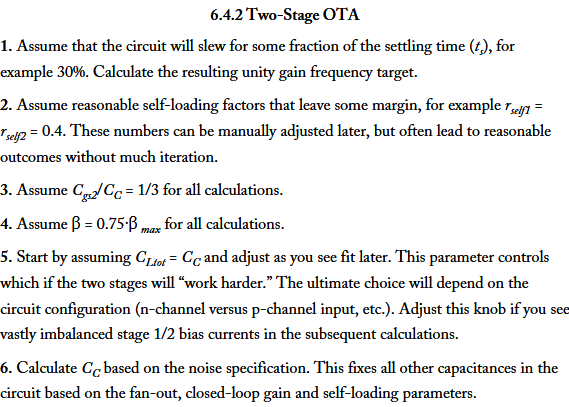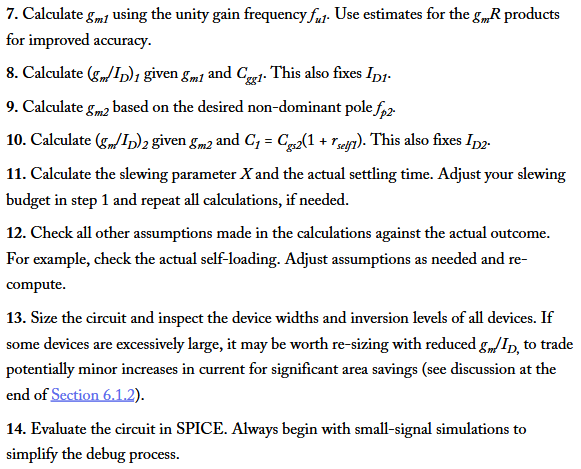

In [ ]:
s = {
    'G'         : 1/4,
    'FO'        : 4,
    'fu1'       : 0,
    'fp2'       : 0,
    'vod_noise' : 90e-6,
    'L0' : 10000,
    'ts' : 50e-9,
    'vod_final' : 160e-3,
    'ed'    : 0.05/100
}
# Constants for another design
d = {
    'L1': 0.5,
    'L4': 0.35,
    'L2': 0.5,
    'L3': 0.35,
    'gam1': 0.8,
    'gam4': 0.8,
    'gam2': 0.8,
    'gam3': 0.8,
    'gm3_gm1': 1.0,
    'gm4_gm2': 0.5,
    'cgs2_cc': 0.5,
    'rself_1': 0,
    'rself_2': 0,
    'beta': beta_max * np.linspace(0.4, 0.9, 10),
    'cltot_cc': np.linspace(0.2, 1.5, 10),
    'gm_id_test': np.linspace(1, 30,15),
    }
#Compute UGBW with settling and error, 
#step 1
s['fu1'] = 1/(2*np.pi) * np.log(1/ s['ed']) / s['ts'] * 1
s['fp2'] = s['fu1'] * 6.0
#step 2
d['rself_1'] = 0.4
d['rself_2'] = 0.4
#step3
d['cgs2_cc'] = 1/3
#step4
beta_max = 1 / (1 + s['G'])
d['beta'] =beta_max * 3/4
#step5
d['cltot_cc'] = 1.3
#step6 -> 10, loop to adjust FU1 and rse
# lf a few time
for i in range(10):
    m1,m2,m3,m4,p = two_stage(nmos4, pmos4, s, d)
    ##Update rself
    d['rself_1'] = p['rself1'].item()
    d['rself_2'] = p['rself2'].item()
    X = s['vod_final'] * d['beta'] / 2 * m1['gmid']
    actual_ts = 1 / s['fu1'] / (2 * np.pi) * (X - 1 + np.log(1/s['ed'] * X))    
    #Update FP1

    wu1 = 1 / s['ts']*(X - 1 + np.log(1/(s['ed']*X)))
    s['fu1'] =  wu1.item() / (2 * np.pi)
    s['fp2'] = s['fu1'] * 4.0
    idtot = (m1['id'] + m2['id'])*1e6

adri.cool_print(idtot,actual_ts, X, wu1, s['fu1'])



#adri.cool_print(idtot, X,wu1,  actual_ts)
print_design_summary(s, d, m1, m2, m3, m4, p)


### All function in one cell

In [1]:
import numpy as np
import scipy.constants as sc
import catppuccin
import matplotlib.pyplot as plt
import adri
from pygmid import Lookup as lk
pmos4 = lk('lookup_table/035/pmos4.mat')
nmos4 = lk('lookup_table/035/nmos4.mat')
#import adri as adri
#22H17
# setup matplotlib
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.spines.top'] = False
plt.rcParams.update({"axes.grid": True})
from scipy.interpolate import interp1d
from IPython.display import display, HTML
def print_design_summary(s, d, m1, m2, m3, m4, p):
    def make_table(title, blk):
        items = [(k, fmt(np.asarray(v).flat[0] if not np.isscalar(v) else v, k))
                 for k, v in blk.items()]
        header = f"<tr><td colspan='2' style='padding:8px 0 3px; font-size:20px; letter-spacing:.1em; opacity:.5; text-transform:uppercase; border-top:1px solid currentColor;'>{title}</td></tr>"
        rows = "".join(
            f"<tr><td style='padding:1px 4px 1px 0; opacity:.6; white-space:nowrap'>{k}</td>"
            f"<td style='padding:1px 0; text-align:right; font-variant-numeric:tabular-nums; font-weight:500; white-space:nowrap'>{v}</td></tr>"
            for k, v in items)
        footer = "<tr><td colspan='2' style='border-top:1px solid currentColor; padding-top:2px'></td></tr>"
        return f"<table style='font-family:monospace; font-size:18px; border-collapse:collapse; color:inherit; vertical-align:top'>{header}{rows}{footer}</table>"

    tables = ""
    for title, blk in [("Specifications", s), ("Design parameters", d),
                        ("M1", m1), ("M2", m2), ("M3", m3), ("M4", m4), ("P", p)]:
        tables += f"<td style='vertical-align:top; padding-right:0px'>{make_table(title, blk)}</td>"

    display(HTML(f"<table style='color:inherit; border-spacing:; border-collapse:collapse'><tr>{tables}</tr></table>"))
def fmt(val, key=""):
    if not isinstance(val, (int, float, np.floating)):
        return str(val)
    a = abs(val)
    if   a >= 1e9:  return f"{val/1e9:.4g} G"
    elif a >= 1:    return f"{val:.4g}"
    elif a >= 1e-3: return f"{val/1e-3:.4g} m"
    elif a >= 1e-6: return f"{val/1e-6:.4g} u"
    elif a >= 1e-9: return f"{val/1e-9:.4g} n"
    elif a >= 1e-12:return f"{val/1e-12:.4g} p"
    else:           return f"{val:.4e}"
def interp1(x, y, value):
    # Interpolation function
    # Perform cubic interpolation using interp1d
    f = interp1d(x, y, kind='cubic')
    return f(value)
def two_stage(nmos, pmos, s, d):
    kBT = 1.3806488e-23 * 300
    beta_arr     = np.atleast_1d(d['beta'])
    cltot_cc_arr = np.atleast_1d(d['cltot_cc'])
    N = len(beta_arr)   # axe 0
    M = len(cltot_cc_arr)  # axe 1
    m1 = {k: np.full((N, M), np.nan) for k in ['W','gm','gmid','cgg','cgd','cdd','ft','id']}
    m2 = {k: np.full((N, M), np.nan) for k in ['W','gm','gmid','cgg','cgd','cdd','ft','id','cgs','fts']}
    m3 = {k: np.full((N, M), np.nan) for k in ['W','gmid','cdd']}
    m4 = {k: np.full((N, M), np.nan) for k in ['W','gmid','cdd']}
    p  = {k: np.full((N, M), np.nan) for k in ['cc','cltot','cf','cs','cl','c1','rz','cn','rself1','rself2','cc_add']}
    m1['L'] = d['L1']
    m2['L'] = d['L2']
    m3['L'] = d['L3']
    m4['L'] = d['L4']

    for j, beta in enumerate(beta_arr):  # j = indice beta → ligne [j,:]
        cc    = (2/beta * kBT * d['gam1'] * (1 + d['gam3']/d['gam1'] * d['gm3_gm1'])
               + 1/cltot_cc_arr * kBT * (1 + d['gam2'] * (1 + d['gam4']/d['gam2'] * d['gm4_gm2']))
               ) / s['vod_noise']**2
        cltot = cc * cltot_cc_arr
        cf    = cltot / (1 + d['rself_2']) / (1 - beta + s['FO'] * s['G'])
        cs    = cf * s['G']
        cl    = cs * s['FO']
        cgs2  = cc * d['cgs2_cc']
        c1    = cgs2 * (1 + d['rself_1'])

        gmR    = np.sqrt(s['L0'] / beta)
        gm1    = (2*np.pi * s['fu1'] * cc / beta
                  * (1 + (1 + c1/cc) / gmR + (1 + cltot/cc) / gmR))
        cgg1   = cf * (1/beta - 1 - s['G'])
        ft1    = gm1 / (2*np.pi * cgg1)
        gmid1  = pmos.lookup('GM_ID', GM_CGG=2*np.pi*ft1, L=d['L1'], WARNING=False)
        id1    = gm1 / gmid1

        gm2    = 2*np.pi * s['fp2'] * c1 * (1 + cltot/cc + cltot/c1)
        fts2   = gm2 / (2*np.pi * cgs2)
        gmid2  = nmos.lookup('GM_ID', GM_CGS=2*np.pi*fts2, L=d['L2'], WARNING=False)
        id2    = gm2 / gmid2

        # Storage [j,:] → ligne j = beta j, colonnes = tous les cltot_cc
        p['cc'][j,:]     = cc
        p['cltot'][j,:]  = cltot
        p['cf'][j,:]     = cf
        p['cs'][j,:]     = cs
        p['cl'][j,:]     = cl
        p['c1'][j,:]     = c1
        m2['cgs'][j,:]   = cgs2
        m1['gm'][j,:]    = gm1
        m1['cgg'][j,:]   = cgg1
        m1['ft'][j,:]    = ft1
        m1['gmid'][j,:]  = gmid1
        m1['id'][j,:]    = id1
        m2['gm'][j,:]    = gm2
        m2['fts'][j,:]   = fts2
        m2['gmid'][j,:]  = gmid2
        m2['id'][j,:]    = id2
        p['rz'][j,:]     = 1 / gm2

        m3['gmid'][j,:]  = gmid1 * d['gm3_gm1']
        m4['gmid'][j,:]  = gmid2 * d['gm4_gm2']
        m1['W'][j,:]     = id1 / pmos.lookup('ID_W', GM_ID=gmid1, L=d['L1'], WARNING=False)
        m2['W'][j,:]     = id2 / nmos.lookup('ID_W', GM_ID=gmid2, L=d['L2'], WARNING=False)
        m3['W'][j,:]     = id1 / nmos.lookup('ID_W', GM_ID=m3['gmid'][j,:], L=d['L3'], WARNING=False)
        m4['W'][j,:]     = id2 / pmos.lookup('ID_W', GM_ID=m4['gmid'][j,:], L=d['L4'], WARNING=False)

        m1['cgd'][j,:]   = m1['W'][j,:] * pmos.lookup('CGD_W', GM_ID=gmid1, L=d['L1'], WARNING=False)
        p['cn'][j,:]     = m1['cgd'][j,:]
        m2['cgd'][j,:]   = m2['W'][j,:] * nmos.lookup('CGD_W', GM_ID=gmid2, L=d['L2'], WARNING=False)
        p['cc_add'][j,:] = cc - m2['cgd'][j,:]

        m1['cdd'][j,:]   = m1['W'][j,:] * pmos.lookup('CDD_W', GM_ID=gmid1, L=d['L1'], WARNING=False)
        m2['cdd'][j,:]   = m2['W'][j,:] * nmos.lookup('CDD_W', GM_ID=gmid2, L=d['L2'], WARNING=False)
        m3['cdd'][j,:]   = m3['W'][j,:] * nmos.lookup('CDD_W', GM_ID=m3['gmid'][j,:], L=d['L3'], WARNING=False)
        m4['cdd'][j,:]   = m4['W'][j,:] * pmos.lookup('CDD_W', GM_ID=m4['gmid'][j,:], L=d['L4'], WARNING=False)

        p['rself1'][j,:] = (m1['cdd'][j,:] + m3['cdd'][j,:]) / m2['cgs'][j,:]
        p['rself2'][j,:] = ((m2['cdd'][j,:] - m2['cgd'][j,:]) + m4['cdd'][j,:]) / (cl + (1 - beta) * cf)

    return m1, m2, m3, m4, p
s = {
    'G'         : 1/4,
    'FO'        : 4,
    'fu1'       : 0,
    'fp2'       : 0,
    'vod_noise' : 90e-6,
    'L0' : 50,
    'ts' : 50e-9,
    'vod_final' : 160e-3,
    'ed'    : 0.05/100
}
# Constants for another design
d = {
    'L1': 0.5,
    'L4': 0.5,
    'L2': 0.5,
    'L3': 0.5,
    'gam1': 0.8,
    'gam4': 0.8,
    'gam2': 0.8,
    'gam3': 0.8,
    'gm3_gm1': 1.0,
    'gm4_gm2': 0.5,
    'cgs2_cc': 0.5,
    'rself_1': 0,
    'rself_2': 0,
    'beta': 0,
    'cltot_cc': 0
    }
#Compute UGBW with settling and error, 
#step 1
s['fu1'] = 1/(2*np.pi) * np.log(1/ s['ed']) / s['ts'] * 1
s['fp2'] = s['fu1'] * 6.0
#step 2
d['rself_1'] = 0.4
d['rself_2'] = 0.4
#step3
d['cgs2_cc'] = 0.3
#step4
beta_max = 1 / (1 + s['G'])
d['beta'] = 3/4 * beta_max
#step5
d['cltot_cc'] = 1
#step6 -> 10, loop to adjust FU1 and rse
# lf a few time
for i in range(7):
    m1,m2,m3,m4,p = two_stage(nmos4, pmos4, s, d)
    ##Update rself
    d['rself_1'] = p['rself1'].item()
    d['rself_2'] = p['rself2'].item()
    X = s['vod_final'] * d['beta'] / 2 * m1['gmid']
    actual_ts = 1 / s['fu1'] / (2 * np.pi) * (X - 1 + np.log(1/s['ed'] * X))    
    #Update FP1

    wu1 = 1 / s['ts']*(X - 1 + np.log(1/(s['ed']*X)))
    s['fu1'] =  wu1.item() / (2 * np.pi)
    s['fp2'] = s['fu1'] * 4.0
    idtot = (m1['id'] + m2['id'])*1e6

adri.cool_print(idtot,actual_ts, X, wu1, s['fu1'])



#adri.cool_print(idtot, X,wu1,  actual_ts)
print_design_summary(s, d, m1, m2, m3, m4, p)



idtot = array([[275.72963564]])
actual_ts = array([[4.67407247e-08]])
X = array([[0.77823756]])
wu1 = array([[1.52597269e+08]])
s['fu1'] = 24286609.738127105
